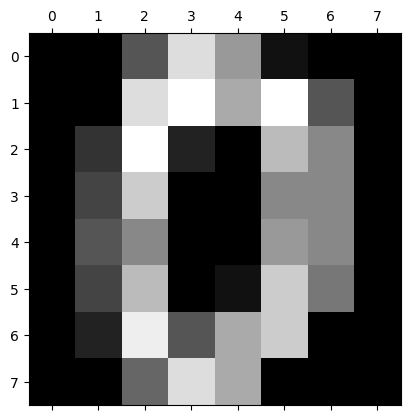

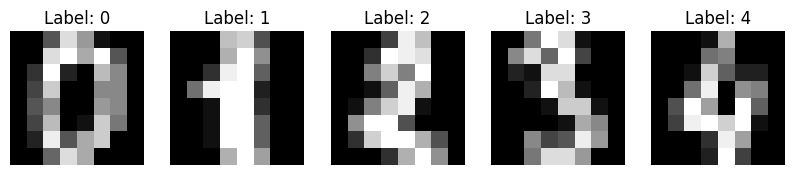

In [109]:

import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
#A quick utility function that centers (mean=0) and scales (std=1) the data
#Without scaling, SVM and KNN can have pixels or features that may dominate bcause of the larger numeric range of the data
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
#1797 samples, 64 features (8x8 images)
digits = load_digits()
# print(digits.data.shape)
X = scale(digits.data)
y = digits.target

plt.matshow(digits.images[0], cmap="gray")
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 4))
for ax, img, label in zip(axes, digits.images[:5], digits.target[:5]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.show()



In [110]:
from sklearn import metrics

from sklearn.model_selection import train_test_split,  KFold

XTrain, Xtest, yTrain, yTest = train_test_split(X,y, test_size=0.2, random_state=42)


SVM Accuracy: 0.9805555555555555


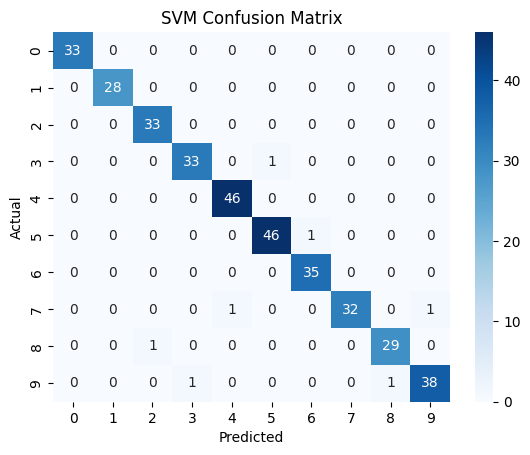

7


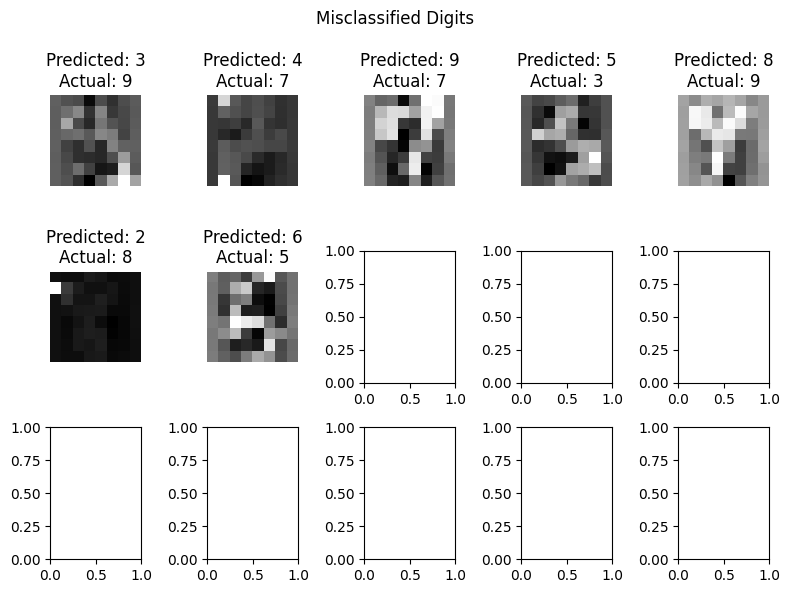

In [111]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Create a SVM Model using rbf kernel and parameter C=100 using the training dataset
svmClassifier = SVC(kernel='rbf', C=100)
svmClassifier.fit(XTrain, yTrain)
# Using the test dataset, evaluate the accuracy of the model. Again using the test dataset, compute teh matrix.
# What is the most common mistake that the classifier makes?
yPrediction = svmClassifier.predict(Xtest)
AccuracySVM = accuracy_score(yTest, yPrediction)
print("SVM Accuracy:", AccuracySVM)
SVMConfustionMatrix = confusion_matrix(yTest, yPrediction)

# Show COnfusion Matrix
sns.heatmap(SVMConfustionMatrix, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot all of these misclassified digits as images.
# Find the indicies of missclassified digits by comparing the predicted labels with the true labels.
# Use the the 0
misclassifiedIndices = np.where(yTest != yPrediction)[0]
misclassified = Xtest[misclassifiedIndices]
print(len(misclassifiedIndices))
fig, axes = plt.subplots(3, 5, figsize=(8, 6))
# For each of the axes, plot the first 15 misclassified digits
for ax, index in zip(axes.ravel(), misclassifiedIndices[:15]):
    img = Xtest[index]
    ax.imshow(img.reshape(8, 8), cmap='gray')
    ax.set_title(f"Predicted: {yPrediction[index]}\nActual: {yTest[index]}")
    ax.axis('off')
plt.suptitle('Misclassified Digits')
plt.tight_layout()
plt.show()



What is the most common mistake the classifier makes?
The most common mistakes for the svm classifier were mistakening the values 9 & 7 for other values.


In [112]:
# Using the 'cross_val_score' function, evaluate the accuracy of the SVM for 100 different
# values of the parameter C between 1 and 500. What is the best value?
from sklearn.model_selection import  cross_val_predict, cross_val_score
from sklearn.svm import SVC
import numpy as np
# Create a range of C values from 1 to 500
AllTheCs = np.linspace(1, 500, 100)
Scores = []
for c in AllTheCs:
    svm = SVC(kernel='rbf', C=c)
    score = cross_val_score(svm, XTrain, yTrain, cv=5).mean()
    Scores.append(score)
# Get the best C value based off the highest accuracy score
BestC = AllTheCs[np.argmax(Scores)]
print(f"Best C: {BestC:.2f}, CV Accuracy: {max(Scores):.4f}")

# Raw Data comparison
Xunscaled = digits.data
XTrainUnscaled, XtestUnscaled, yTrainUnscaled, yTestUnscaled = train_test_split(Xunscaled, y, test_size=0.2, random_state=42)
# Keep C and kernel constant, but change the data to unscaled
svmClassifierUnscaled = SVC(kernel='rbf', C=100)
svmClassifierUnscaled.fit(XTrainUnscaled, yTrainUnscaled)
print(f"SVM Accuracy on Unscaled Data: {svmClassifierUnscaled.score(XtestUnscaled, yTestUnscaled):.4f}")






Best C: 11.08, CV Accuracy: 0.9798
SVM Accuracy on Unscaled Data: 0.9861


What is the best value?
The best C was 11.8. 
What’s your accuracy score?
The accuracy score was 0.986 but this doesn't necessarily make it better, both accuaracies are already high and getting that high of a score could had been due to a bad training split. The CV process gives us a better examination of the data and developes a more full picture.

KNN Accuracy with k=10: 0.9722


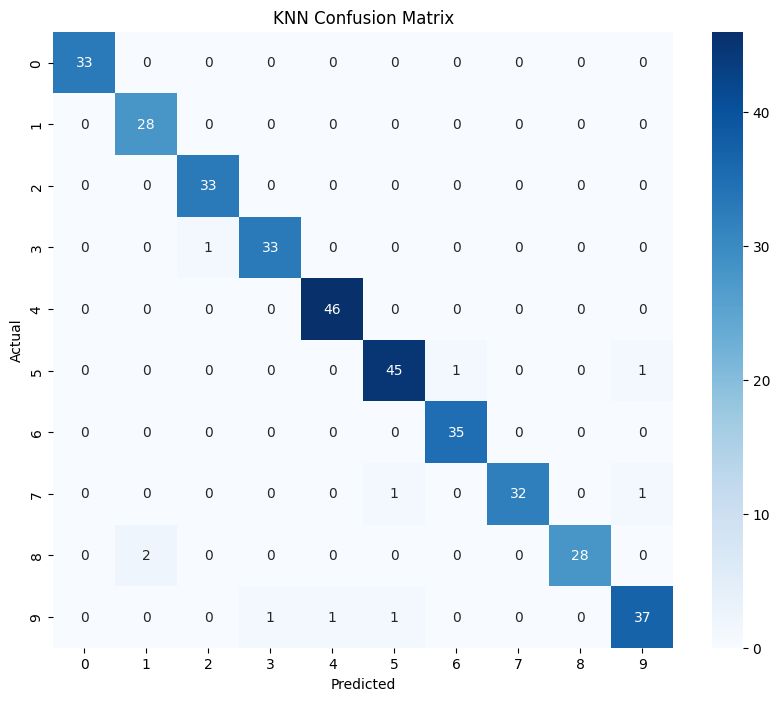

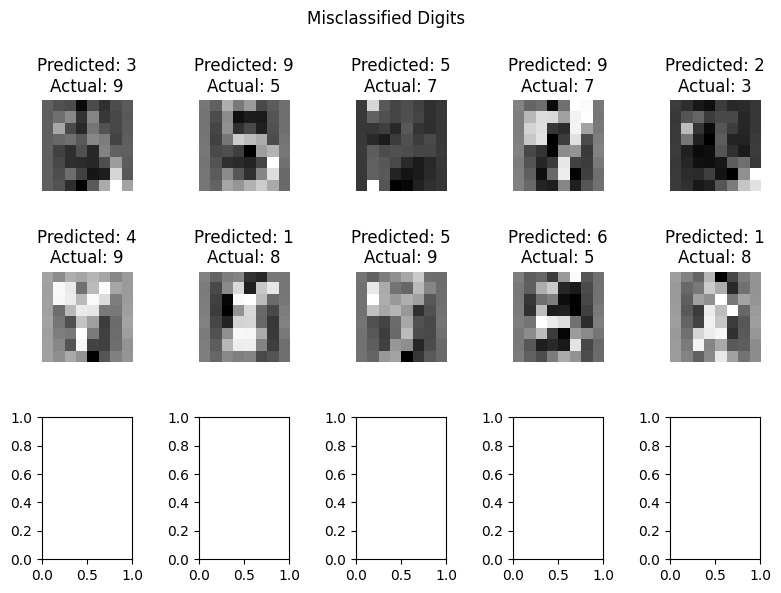

k=1, CV Accuracy: 0.9666
k=2, CV Accuracy: 0.9617
k=3, CV Accuracy: 0.9743
k=4, CV Accuracy: 0.9680
k=5, CV Accuracy: 0.9729
k=6, CV Accuracy: 0.9694
k=7, CV Accuracy: 0.9729
k=8, CV Accuracy: 0.9701
k=9, CV Accuracy: 0.9673
k=10, CV Accuracy: 0.9631
k=11, CV Accuracy: 0.9631
k=12, CV Accuracy: 0.9589
k=13, CV Accuracy: 0.9583
k=14, CV Accuracy: 0.9555
k=15, CV Accuracy: 0.9527
k=16, CV Accuracy: 0.9548
k=17, CV Accuracy: 0.9541
k=18, CV Accuracy: 0.9520
k=19, CV Accuracy: 0.9492
k=20, CV Accuracy: 0.9499
KNN Accuracy on Unscaled Data: 0.9833


In [113]:
from sklearn.neighbors import KNeighborsClassifier
# Repeat the same experiments as you did with the SVM. Start with a k of 10 for the first experiment
# and then try to find a good value of k using cross_val_score
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(XTrain, yTrain)
KnnAccuracy = knn.score(Xtest, yTest)
print(f"KNN Accuracy with k=10: {KnnAccuracy:.4f}")

# Compute the confusion matrix and find the most common mistakes
knnCM = confusion_matrix(yTest, knn.predict(Xtest))
plt.figure(figsize=(10, 8))
sns.heatmap(knnCM, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

misclassifiedIndices = np.where(yTest != knn.predict(Xtest))[0]
misclassified = Xtest[misclassifiedIndices]
fig, axes = plt.subplots(3, 5, figsize=(8, 6))
for ax, index in zip(axes.ravel(), misclassifiedIndices[:15]):
    img = Xtest[index]
    ax.imshow(img.reshape(8, 8), cmap='gray')
    ax.set_title(f"Predicted: {knn.predict(Xtest)[index]}\nActual: {yTest[index]}")
    ax.axis('off')
plt.suptitle('Misclassified Digits')
plt.tight_layout()
plt.show()

# Using cross_val_score to find the best k value
kValues = range(1,21)
kScores = []
for k in kValues:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, XTrain, yTrain, cv=5)
    kScores.append(scores.mean())
    print(f"k={k}, CV Accuracy: {scores.mean():.4f}")

# Training and testing KNN on raw unscaled data
knnUnscaled = KNeighborsClassifier(n_neighbors=10)
knnUnscaled.fit(XTrainUnscaled, yTrainUnscaled)
print(f"KNN Accuracy on Unscaled Data: {knnUnscaled.score(XtestUnscaled, yTestUnscaled):.4f}")


Evaluate the accuracy using the test dataset.
Answer:
The accuracy was .9722 which is super accurate.

What is the most common mistake the classifier makes?
Answer:
The most common mistakes were for the values of 9 and 7. But interestingly enough 8 was misclassified twice and each time it was predicted at a 1. I suppose this is because 1 is also concentrated in the center of the 8x8.

What is the best value?
Answer:
The best CV score was k=3: Accuracy was .9743.

What's the accuracy score for knn on the raw data?
Answer:
The accuracy score was higher than the test using training data, I would assume that the data is already scaled or that we got extremely lucky.

### Part 2: Unsupervised Clustering on Human Activity Recognition Data
The Human Activity Recognition (HAR) dataset contains accelerometer and gyroscope readings collected from a smartphone worn by participants during daily activities. These include walking, sitting, standing, laying down, and moving up/down stairs.

Each observation is a feature vector summarizing sensor readings over a time window. Though the dataset includes labels, you will not use these labels for clustering, only for post-hoc evaluation.

Classes (for evaluation only): 6
(WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
Samples: 7352
Features: 561 numeric (time + frequency domain)




In [114]:
# Import the data
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = pd.read_csv('X_train.txt', delim_whitespace=True, header=None)
y = pd.read_csv('y_train.txt', delim_whitespace=True, header=None).squeeze()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)







/var/folders/g7/6tmkmhfx0ks5j72hk5_ty7rm0000gn/T/ipykernel_40192/3526892878.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X = pd.read_csv('X_train.txt', delim_whitespace=True, header=None)
/var/folders/g7/6tmkmhfx0ks5j72hk5_ty7rm0000gn/T/ipykernel_40192/3526892878.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y = pd.read_csv('y_train.txt', delim_whitespace=True, header=None).squeeze()


Step 2: Dimensionality Reduction
Use PCA to reduce dimensions:

2 components for visualization
50 components for clustering
Visualize the 2D projection, coloring by true activity labels.

(7352, 2)


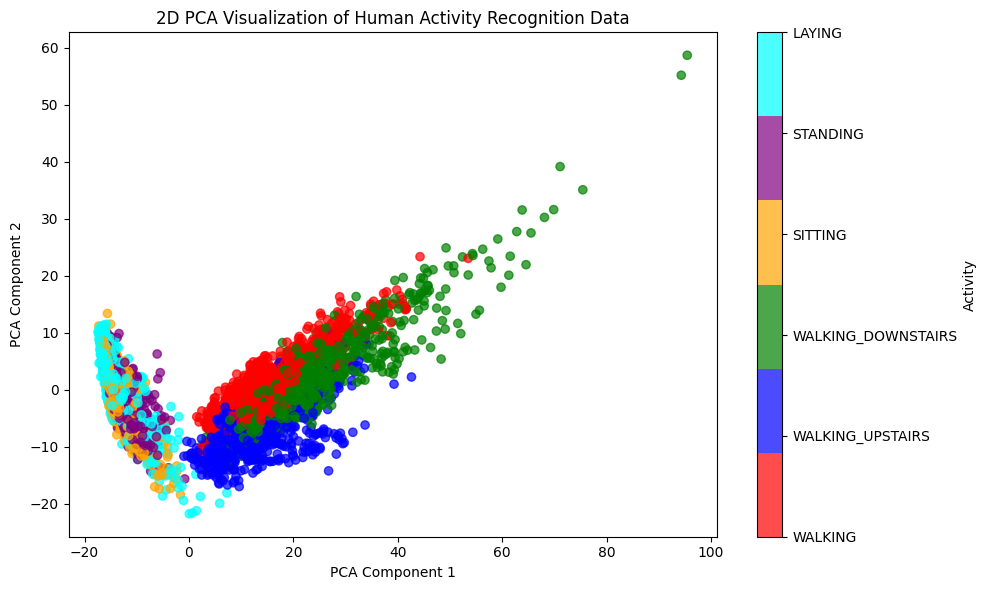

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

PCA2d =PCA(n_components=2)
XPCA2d = PCA2d.fit_transform(X_scaled)

print(XPCA2d.shape)
myColors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
customCmap = ListedColormap(myColors)

# Scatter plot with custom colormap
plt.figure(figsize=(10, 6))
scatter = plt.scatter(XPCA2d[:, 0], XPCA2d[:, 1], c=y-1, cmap=customCmap, alpha=0.7)

# Add colorbar with correct labels
cbar = plt.colorbar(scatter, ticks=np.arange(6))
cbar.set_ticklabels(['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 
                     'SITTING', 'STANDING', 'LAYING'])
cbar.set_label('Activity')

plt.title('2D PCA Visualization of Human Activity Recognition Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

In [116]:
# 50 components for clustering
PCA50d = PCA(n_components=50)
XPCA50d = PCA50d.fit_transform(X_scaled)
print(XPCA50d.shape)
print(PCA50d.explained_variance_ratio_[:20])
print(PCA50d.explained_variance_ratio_.sum())
# This gives us 87.5% of the variance in teh data across the first 50 components

(7352, 50)
[0.50781172 0.0658068  0.02806437 0.02503953 0.01888285 0.01724006
 0.01371011 0.01199078 0.0099586  0.00965087 0.00860052 0.00800281
 0.00763996 0.00645329 0.00632324 0.00599722 0.0058675  0.00575407
 0.00567921 0.00527296]
0.875183635831662


Step 3: K-Means Clustering
Apply K-Means with n_clusters=6 on the 50D data.
Visualize the clustering in the 2D PCA projection.
Report: Silhouette Score, the elbow score.
Try different values of k from 2–12. Plot the elbow curve and silhouette scores.

Kmeans Silhouette Score (k =6): 0.1508


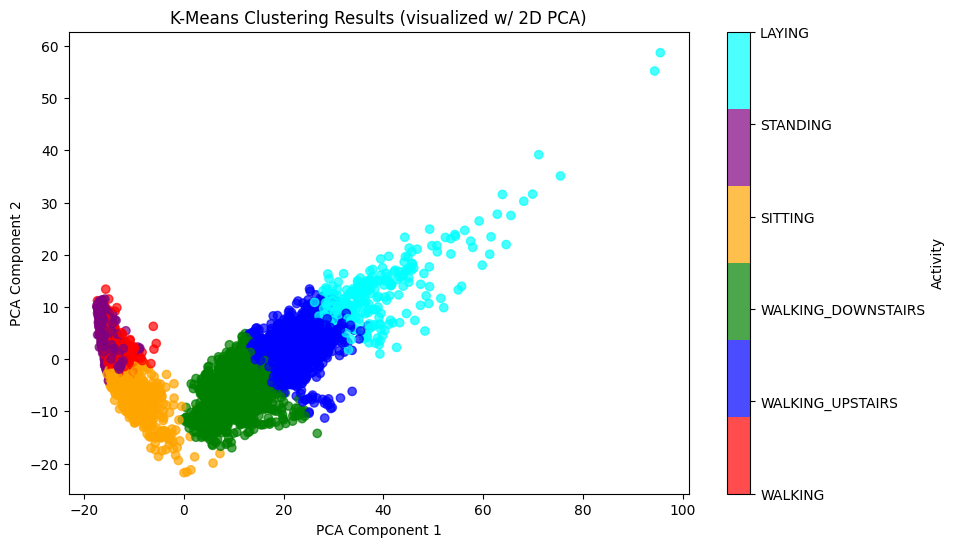

In [132]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Apply K-Means with n_clusters=6 on the 50D data.
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
# Fit the KMeans model to the 50D PCA data
kmeans.fit(XPCA50d)
clusterLabels = kmeans.labels_

silhouetteScore = silhouette_score(XPCA50d, clusterLabels)
print(f"Kmeans Silhouette Score (k =6): {silhouetteScore:.4f}")


# Visualize the clustering in the 2D PCA projection.
plt.figure(figsize= (10, 6))
scatter = plt.scatter(XPCA2d[:, 0], XPCA2d[:, 1], c=clusterLabels, cmap=customCmap, alpha=0.7)
cbar = plt.colorbar(scatter, ticks=np.arange(6))
cbar.set_ticklabels(['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 
                     'SITTING', 'STANDING', 'LAYING'])
cbar.set_label('Activity')
plt.title('K-Means Clustering Results (visualized w/ 2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


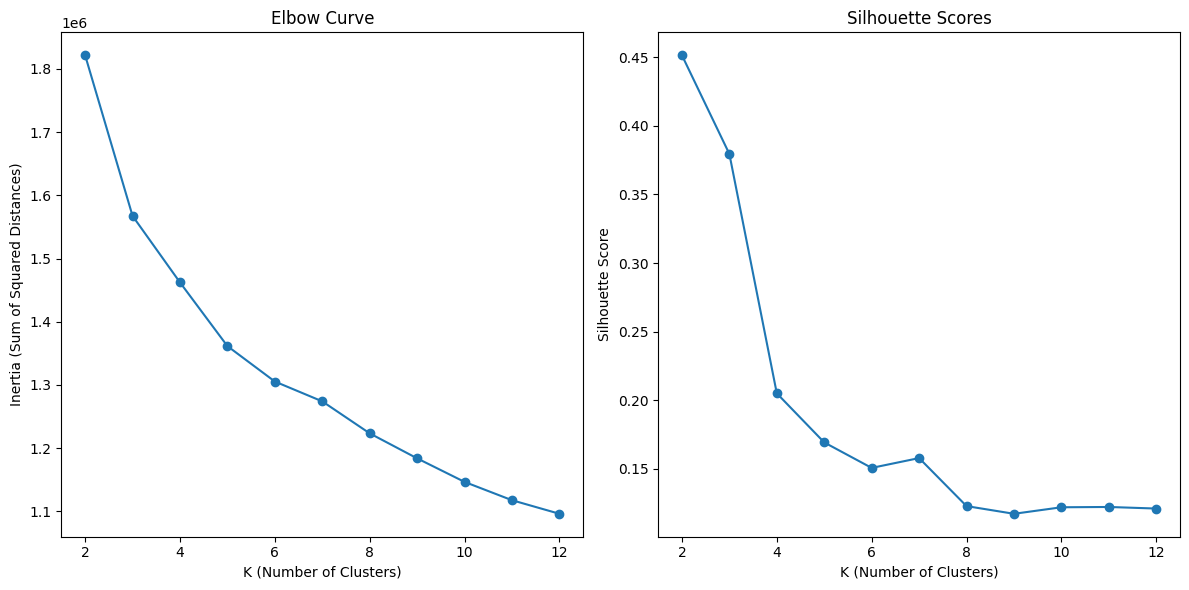

In [118]:
# Try different values of k from 2–12. Plot the elbow curve and silhouette scores.
inertiaScores = [] # sum of squared distances to cluster centers - how compact are the clusters?

silhouetteScores = [] # silhouette score - how well separated are the clusters?
kRange = range(2, 13)
for k in kRange:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(XPCA50d)
    inertiaScores.append(kmeans.inertia_)
    silhouetteScores.append(silhouette_score(XPCA50d, kmeans.labels_))
# Plot the elbow curve
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(kRange, inertiaScores, marker='o')
plt.title("Elbow Curve")
plt.xlabel("K (Number of Clusters)")
plt.ylabel("Inertia (Sum of Squared Distances)")

# Silhouette Score Plot
plt.subplot(1, 2, 2)
plt.plot(kRange, silhouetteScores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("K (Number of Clusters)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()



Step 4: Hierarchical Clustering
Use Agglomerative Clustering with linkage='ward', n_clusters=6
Visualize the clustering on 2D PCA
Plot a dendrogram for a 100-sample subset
Report silhouette score and ARI

Agglomerative Clustering Silhouette Score (k=6): 0.1125
Adjusted Rand Index (ARI): 0.4781


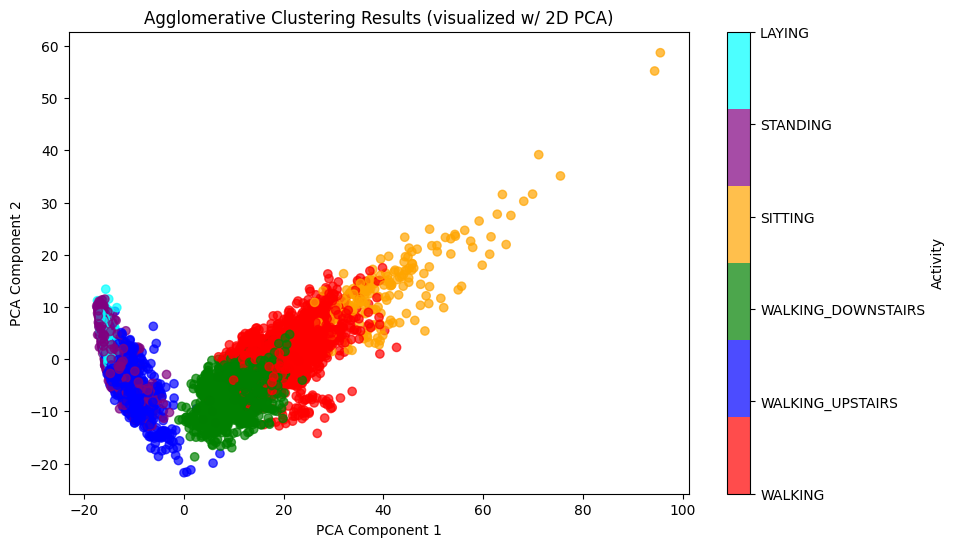

In [133]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
# Use Agglomerative Clustering with linkage='ward', n_clusters=6
aggolomerative = AgglomerativeClustering(n_clusters = 6, linkage='ward')
aggolo = aggolomerative.fit(XPCA50d)

# Report silhouette score
silhouetteScoreAgg = silhouette_score(XPCA50d, aggolo.labels_)
print(f"Agglomerative Clustering Silhouette Score (k=6): {silhouetteScoreAgg:.4f}")
ari = adjusted_rand_score(y, aggolo.labels_)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
# Visualize the clustering on 2D PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(XPCA2d[:, 0], XPCA2d[:, 1], c=aggolo.labels_, cmap=customCmap, alpha=0.7)
cbar = plt.colorbar(scatter, ticks=np.arange(6))
cbar.set_ticklabels(['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 
                     'SITTING', 'STANDING', 'LAYING'])
cbar.set_label('Activity')
plt.title('Agglomerative Clustering Results (visualized w/ 2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


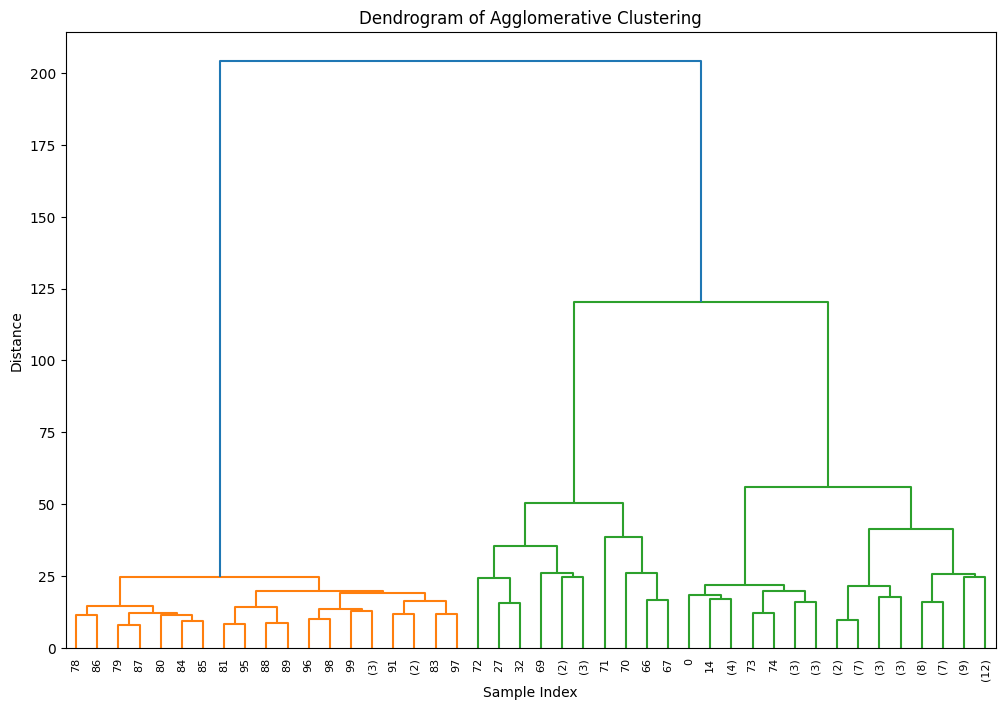

In [120]:
# Plot a dendrogram for a 100-sample subset
from scipy.cluster.hierarchy import dendrogram, linkage

subset = XPCA50d[:100]  # Take the first 100 samples for dendrogram
linked = linkage(subset, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram of Agglomerative Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

Step 5: t-SNE Visualization (Optional)
Try t-SNE to visualize the data. 

/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE shape: (7352, 2)


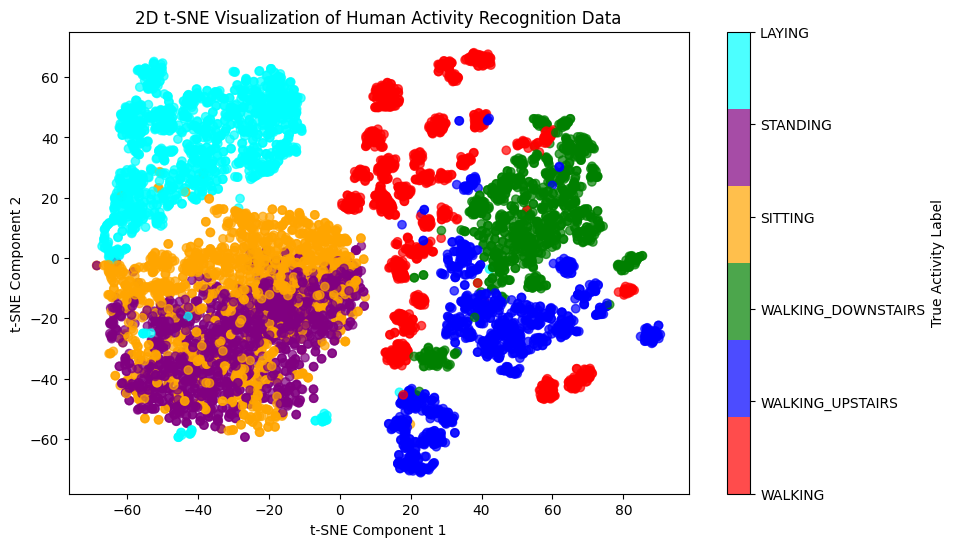

In [135]:
from sklearn.manifold import TSNE

# Reduce 50D PCA data to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
XTSNE2d = tsne.fit_transform(XPCA50d)

print("t-SNE shape:", XTSNE2d.shape)

plt.figure(figsize=(10, 6))
plt.scatter(XTSNE2d[:, 0], XTSNE2d[:, 1], c=y-1, cmap=customCmap, alpha=0.7)
plt.title('2D t-SNE Visualization of Human Activity Recognition Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
cbar = plt.colorbar(label='True Activity Label', ticks=range(6))
cbar.set_ticklabels(['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING'])

plt.show()

Step 6: Evaluation and Reflection

Which algorithm gave more coherent clusters?
Answer:
The Kmeans clustering Silohouette Score of 0.15 was better than the agglomerative Silohouette Score of 0.11. Both of the scores seem relatively weak but this is still satisifying to observe 561 features be visualized in 2 dimensions.

Did dimensionality reduction help?
Answer:
Yes, dimensionality reduction helped, with PCA we reduced the features from 561 to 50 while being able to explain 87.5% of the total variance.
The clustering from teh t-SNE model seemed to have more well defined clusters for walking up stairs, sitting, walking downstairs and laying. However, there still wasn't super clear boundaries in my limited experience of visualization but different human activity is pretty related in the grand scheme of things, and having the smartphone around the waist could be limiting just how different activities can be. The video looks like the participant is performing the actions as formally as possible but without knowing the instructions confidently before hand in some cases. Personally, I would go upstairs hinged forward from my waist more, maybe this would be better (or worse) for data, none the less I'm sure the volunteers performed actions differently than others, as well as differently compared to how they normally might.
Despite these experimental challenges, DR definitely helped to uncover structure in the data.

How well did clustering match the activity labels?
Answer:
The ARI, we were able to come compare our clustering results with our actual acitivity labels and we were able to get a decent score of 0.48. This was alot better than any other score we got, and it's cool to see unsupervised learning be able to find some patterns in physical activites.

What could you do without having access to any labels?
Answer:
Well we saw that we can still utilize unsupervised learning techniques. And even if we don't have labels we can still use the KMeans, Agglomerative Clustering, Elbow Method and Silhouette Scores to develope some percieved seperation. We can't really categorized the data right of the bat but we can use the methods to explore, create new hypotheses and find interesting artifacts. All data is good data.

